# Combo Transaction Volume Exploration

This notebook explores the synthetic transaction volume dataset across 4 independent network/transaction-type combinations:

| Combo | Network | Txn Type | Base Rate | Period | Peak Hour(s) |
|-------|---------|----------|-----------|--------|--------------|
| Accel_CMP | Accel | CMP | ~1765/hr | 24h | ~6 |
| Accel_nopin | Accel | no-pin | ~1370/hr | 12h | ~2, ~14 |
| Star_CMP | Star | CMP | ~2000/hr | 24h | ~18 |
| Star_nopin | Star | no-pin | ~1252/hr | 8h | ~2, ~8, ~14, ~20 |

We examine:
- Per-combo hourly count patterns and daily cycles
- Frequency analysis (FFT) showing each combo's dominant periodicity
- Injected anomaly periods: **spikes** (3x volume surge), **dips** (90% drop), and **ramps** (gradual increase)
- Why the same **FCVAE (Frequency-enhanced Conditional Variational Autoencoder)** architecture can handle all 4 frequency patterns

The FCVAE conditions on frequency-domain features extracted via **FFT (Fast Fourier Transform)**:
- **GFM (Global Frequency Module)**: FFT of the entire 24-hour window for overall periodicity
- **LFM (Local Frequency Module)**: FFT of 8-hour sub-windows + self-attention for local trends

This notebook motivates why volume anomaly detection across diverse periodicities is well-suited for the FCVAE approach.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "code":
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "pyproject.toml").exists(), f"PROJECT_ROOT={PROJECT_ROOT} missing pyproject.toml"
sys.path.insert(0, str(PROJECT_ROOT))

import logging
for name in ["src.model", "src.scorer", "src.preprocess", "src.train"]:
    logging.getLogger(name).setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = PROJECT_ROOT / "data"
print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")

Project root: /Users/jonpaino/Documents/Striim/fcvae-anomaly-detection
Data dir: /Users/jonpaino/Documents/Striim/fcvae-anomaly-detection/data


## 1. Load and Aggregate by Combo

Each combo is a (network_type, transaction_type) pair. We aggregate raw transactions into hourly counts per combo — this is the time series each FCVAE model learns to reconstruct.

In [2]:
from src.preprocess import load_combo_data, COMBO_KEYS

csv_path = DATA_DIR / "synthetic_transactions.csv"
combo_data = load_combo_data(csv_path)

# Also load raw data for overview
df = pd.read_csv(csv_path, parse_dates=["timestamp"])
print(f"Total transactions: {len(df):,}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nPer-combo breakdown:")
combo_counts = df.groupby(["network_type", "transaction_type"]).size()
for (net, txn), count in combo_counts.items():
    pct = count / len(df) * 100
    print(f"  {net}/{txn}: {count:>10,} ({pct:.1f}%)")

Total transactions: 8,852,859
Date range: 2025-01-06 00:00:01.054827896 to 2025-03-06 23:59:59.962628687

Per-combo breakdown:
  Accel/CMP:  2,439,200 (27.6%)
  Accel/no-pin:  1,870,812 (21.1%)
  Star/CMP:  2,798,320 (31.6%)
  Star/no-pin:  1,744,527 (19.7%)


In [3]:
# Summary stats per combo
combo_labels = {
    ("Accel", "CMP"): "Accel_CMP",
    ("Accel", "no-pin"): "Accel_nopin",
    ("Star", "CMP"): "Star_CMP",
    ("Star", "no-pin"): "Star_nopin",
}

print(f"{'Combo':<15} {'Hours':>6} {'Total Txns':>12} {'Mean/hr':>10} {'Std/hr':>10} {'Min':>6} {'Max':>6} {'Anom hrs':>9}")
print("-" * 82)
for combo in COMBO_KEYS:
    h = combo_data[combo]
    label = combo_labels[combo]
    print(f"{label:<15} {len(h):>6} {h['count'].sum():>12,} {h['count'].mean():>10.1f} "
          f"{h['count'].std():>10.1f} {h['count'].min():>6} {h['count'].max():>6} {h['is_anomaly'].sum():>9}")

Combo            Hours   Total Txns    Mean/hr     Std/hr    Min    Max  Anom hrs
----------------------------------------------------------------------------------
Accel_CMP         1440    2,439,200     1693.9     1116.2      0   9987        41
Accel_nopin       1440    1,870,812     1299.2      808.2      0   7424        41
Star_CMP          1440    2,798,320     1943.3     1319.1      0  13101        41
Star_nopin        1440    1,744,527     1211.5      710.7      7   7408        41


## 2. Full Time Series: 60 Days

Each combo's hourly volume over the full dataset with train/val/test splits shaded. Anomaly hours are marked in red.

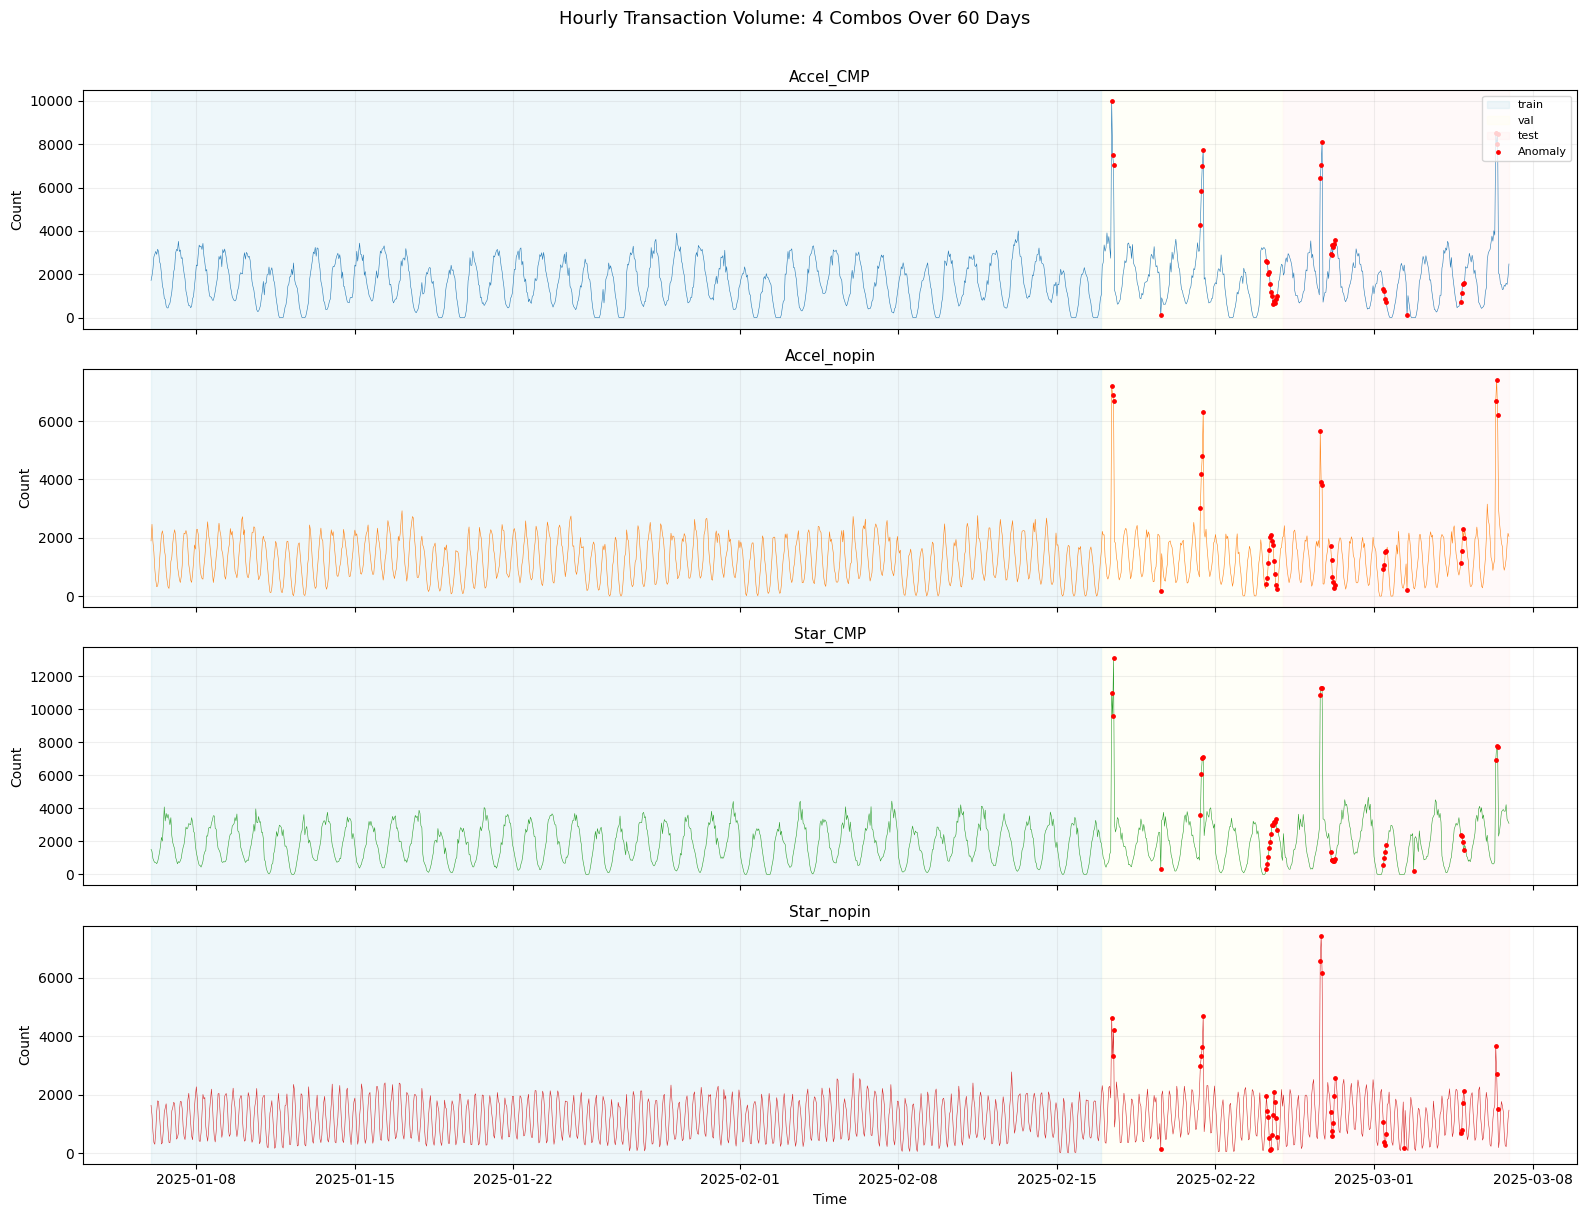

In [4]:
colors = {"Accel_CMP": "#1f77b4", "Accel_nopin": "#ff7f0e", "Star_CMP": "#2ca02c", "Star_nopin": "#d62728"}

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

for i, combo in enumerate(COMBO_KEYS):
    ax = axes[i]
    h = combo_data[combo]
    label = combo_labels[combo]
    
    ax.plot(h["hour_bucket"], h["count"], linewidth=0.4, color=colors[label])
    
    # Shade splits
    if "split" in h.columns:
        for split_name, scolor in [("train", "lightblue"), ("val", "lightyellow"), ("test", "mistyrose")]:
            mask = h["split"] == split_name
            if mask.sum() > 0:
                start = h.loc[mask, "hour_bucket"].min()
                end = h.loc[mask, "hour_bucket"].max()
                ax.axvspan(start, end, alpha=0.2, color=scolor, label=split_name if i == 0 else None)
    
    # Anomaly hours
    anom_mask = h["is_anomaly"] == 1
    if anom_mask.sum() > 0:
        ax.scatter(h.loc[anom_mask, "hour_bucket"], h.loc[anom_mask, "count"],
                   color="red", s=6, zorder=5, label="Anomaly" if i == 0 else None)
    
    ax.set_ylabel("Count")
    ax.set_title(label, fontsize=11)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Time")
axes[0].legend(loc="upper right", fontsize=8)
fig.suptitle("Hourly Transaction Volume: 4 Combos Over 60 Days", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 3. Daily Periodicity: Overlaid Days

Overlay the first 14 training days per combo to visualize the repeating intraday pattern. Note:
- **Accel_CMP** and **Star_CMP**: single 24h cycle (one peak per day)
- **Accel_nopin**: 12h cycle (two peaks per day)
- **Star_nopin**: 8h cycle (three peaks per day)

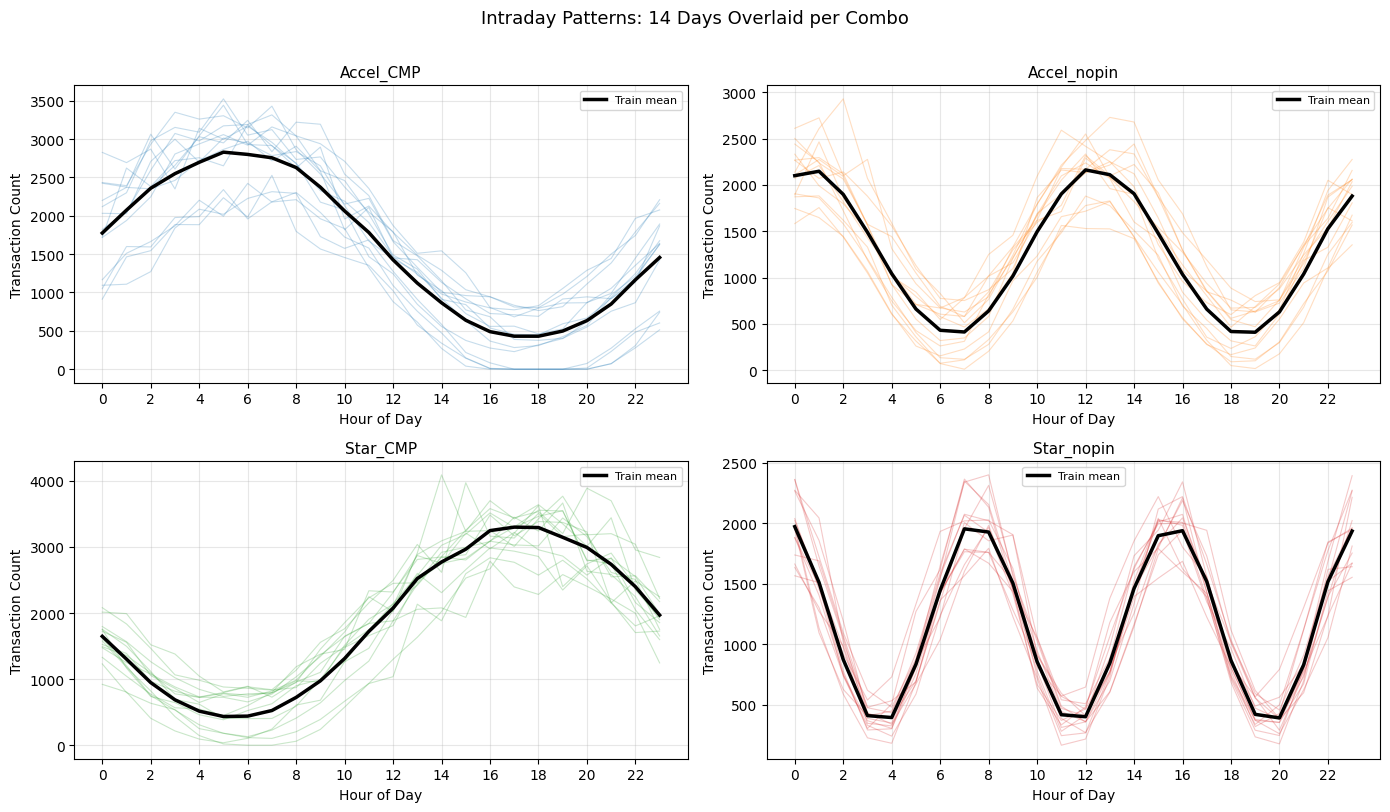

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, combo in enumerate(COMBO_KEYS):
    ax = axes[i // 2][i % 2]
    h = combo_data[combo]
    label = combo_labels[combo]
    counts = h["count"].values
    
    # Overlay first 14 days
    for d in range(min(14, len(counts) // 24)):
        day_counts = counts[d * 24 : (d + 1) * 24]
        ax.plot(range(24), day_counts, alpha=0.25, color=colors[label], linewidth=0.8)
    
    # Mean of training days (first 42)
    train_days = min(42, len(counts) // 24)
    daily_matrix = counts[:train_days * 24].reshape(-1, 24)
    mean_day = daily_matrix.mean(axis=0)
    ax.plot(range(24), mean_day, color="black", linewidth=2.5, label="Train mean")
    
    ax.set_title(f"{label}", fontsize=11)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Transaction Count")
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Intraday Patterns: 14 Days Overlaid per Combo", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 4. Frequency Analysis (FFT)

Apply **FFT (Fast Fourier Transform)** to each combo's training data to identify the dominant periodicities.

This is exactly what the FCVAE's **GFM (Global Frequency Module)** does internally — it applies FFT to each 24-hour input window to extract the dominant frequency components as a conditioning signal. The different dominant periods per combo (24h, 12h, 8h) are why frequency conditioning is powerful: the same architecture adapts to each combo's unique periodicity.

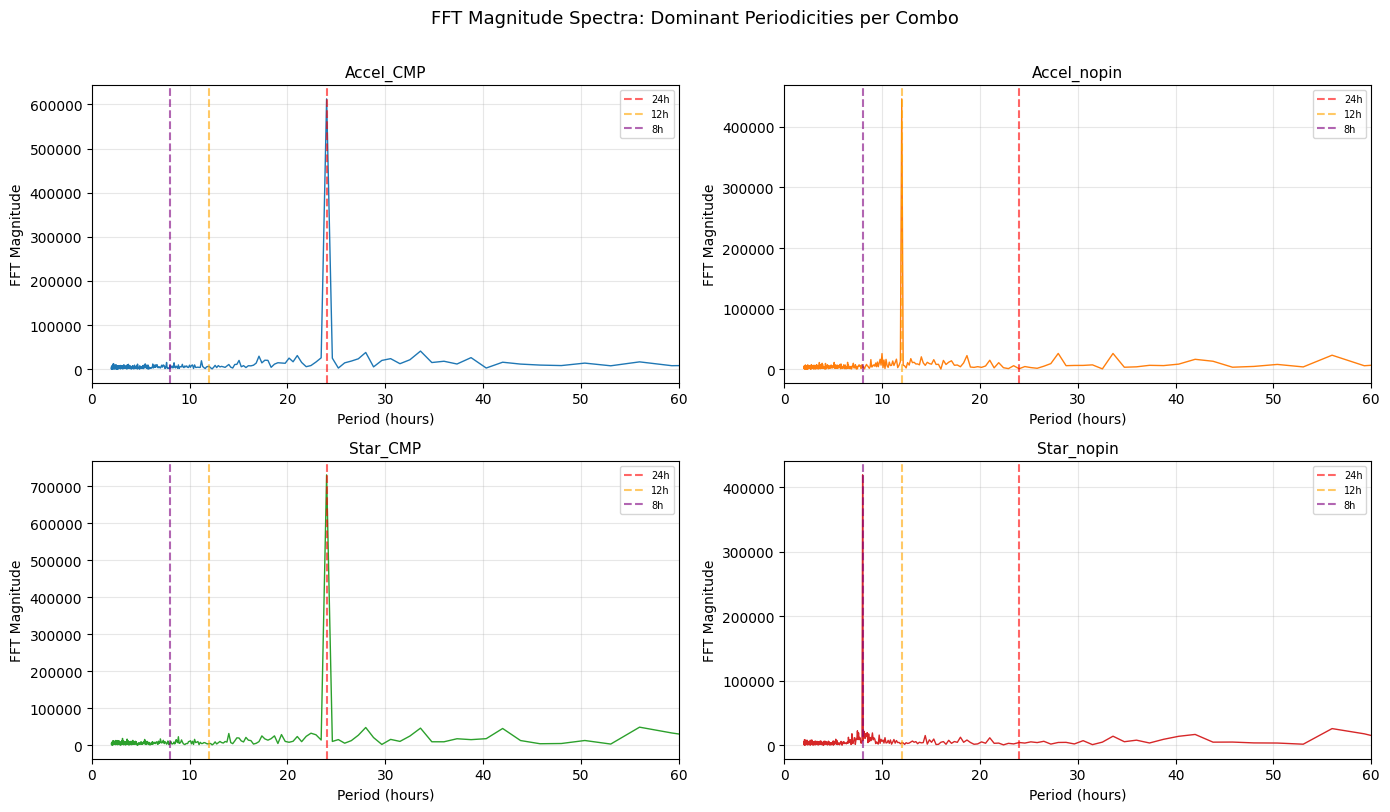

Accel_CMP        Top periods: 24.0h, 168.0h, 84.0h
Accel_nopin      Top periods: 12.0h, 168.0h, 84.0h
Star_CMP         Top periods: 24.0h, 84.0h, 168.0h
Star_nopin       Top periods: 8.0h, 168.0h, 84.0h


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, combo in enumerate(COMBO_KEYS):
    ax = axes[i // 2][i % 2]
    h = combo_data[combo]
    label = combo_labels[combo]
    
    # Use training data only (first 42 days)
    train_counts = h["count"].values[:42 * 24].astype(np.float64)
    train_counts -= train_counts.mean()
    
    fft_vals = np.fft.rfft(train_counts)
    fft_magnitude = np.abs(fft_vals)
    freqs = np.fft.rfftfreq(len(train_counts), d=1.0)
    
    # Convert to periods
    periods = np.zeros_like(freqs)
    periods[0] = np.inf
    periods[1:] = 1.0 / freqs[1:]
    
    # Plot by period (skip DC, zoom to 1-100h)
    mask = (periods > 1) & (periods < 100)
    ax.plot(periods[mask], fft_magnitude[mask], color=colors[label], linewidth=1)
    
    # Reference lines
    ax.axvline(24, color="red", linestyle="--", alpha=0.6, label="24h")
    ax.axvline(12, color="orange", linestyle="--", alpha=0.6, label="12h")
    ax.axvline(8, color="purple", linestyle="--", alpha=0.6, label="8h")
    
    ax.set_title(f"{label}", fontsize=11)
    ax.set_xlabel("Period (hours)")
    ax.set_ylabel("FFT Magnitude")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 60)

fig.suptitle("FFT Magnitude Spectra: Dominant Periodicities per Combo", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

# Print top frequencies per combo
for combo in COMBO_KEYS:
    h = combo_data[combo]
    label = combo_labels[combo]
    train_counts = h["count"].values[:42 * 24].astype(np.float64)
    train_counts -= train_counts.mean()
    fft_vals = np.fft.rfft(train_counts)
    fft_mag = np.abs(fft_vals)
    freqs = np.fft.rfftfreq(len(train_counts), d=1.0)
    periods = np.zeros_like(freqs)
    periods[0] = np.inf
    periods[1:] = 1.0 / freqs[1:]
    
    top_idx = np.argsort(fft_mag[1:])[-3:][::-1] + 1
    tops = ", ".join(f"{periods[j]:.1f}h" for j in top_idx)
    print(f"{label:15s}  Top periods: {tops}")

## 5. Normal vs Anomaly Periods

The dataset has injected anomalies in both validation and test splits:

**Validation (days 43-50):**
- Day 43: **Spike** 3.0x at hours 10-12
- Day 45: **Dip** 0.1x (90% drop) at hour 14
- Day 47: **Ramp** 1.5x→2.5x at hours 8-11
- Day 50: **Duration shift** +3 hours (timing anomaly)

**Test (days 51-60):**
- Day 52: **Spike** 3.0x at hours 15-17
- Day 56: **Dip** 0.1x at combo-specific peak hours
- Day 60: **Spike** 2.5x at hours 9-11

Unlike the penny use case (spikes only), combo anomalies go in **both directions**.

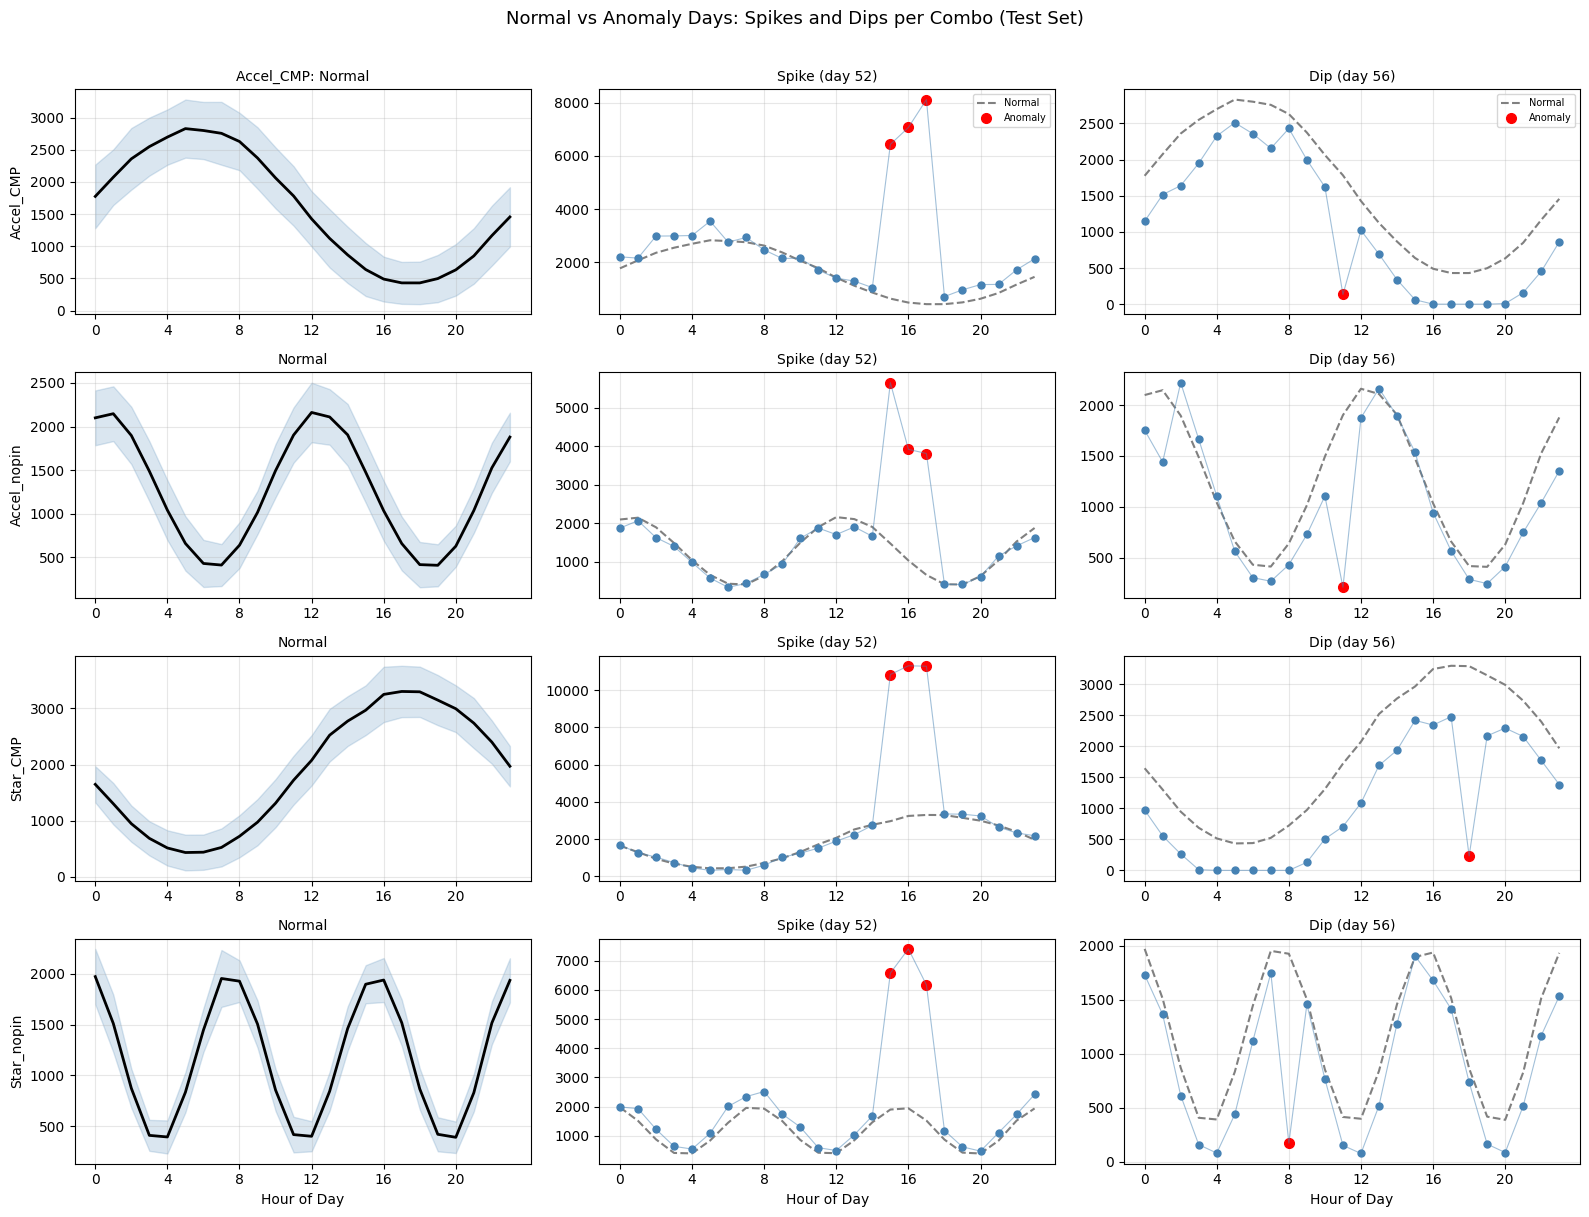

In [7]:
# Plot test anomaly days vs normal baseline per combo
# Known anomaly schedule (from generate_transactions.py):
#   Test offset 1 (day 52): spike 3.0x at hours 15-17
#   Test offset 5 (day 56): dip 0.1x at combo-specific peak hours
SPIKE_OFFSET = 1   # test_daily index for day 52
DIP_OFFSET = 5     # test_daily index for day 56

fig, axes = plt.subplots(4, 3, figsize=(16, 12))

for i, combo in enumerate(COMBO_KEYS):
    h = combo_data[combo]
    label = combo_labels[combo]
    counts = h["count"].values
    anomalies = h["is_anomaly"].values
    
    # Normal baseline (train mean)
    train_days = min(42, len(counts) // 24)
    daily_matrix = counts[:train_days * 24].reshape(-1, 24)
    mean_day = daily_matrix.mean(axis=0)
    std_day = daily_matrix.std(axis=0)
    
    # Col 0: Normal baseline
    ax = axes[i][0]
    ax.plot(range(24), mean_day, color="black", linewidth=2)
    ax.fill_between(range(24), mean_day - std_day, mean_day + std_day, alpha=0.2, color="steelblue")
    ax.set_title(f"{label}: Normal" if i == 0 else "Normal", fontsize=10)
    if i == 0:
        ax.set_ylabel("Count")
    ax.set_xticks(range(0, 24, 4))
    ax.grid(True, alpha=0.3)
    
    # Test period
    test_start_hour = 50 * 24
    test_end_hour = min(60 * 24, len(counts))
    test_hours = test_end_hour - test_start_hour
    test_n_days = test_hours // 24
    
    if test_n_days > 0:
        test_daily = counts[test_start_hour:test_start_hour + test_n_days * 24].reshape(-1, 24)
        test_anom = anomalies[test_start_hour:test_start_hour + test_n_days * 24].reshape(-1, 24)
    
    # Col 1: Spike day (test offset 1 = day 52)
    ax = axes[i][1]
    if test_n_days > SPIKE_OFFSET:
        day_vals = test_daily[SPIKE_OFFSET]
        day_anom = test_anom[SPIKE_OFFSET].astype(bool)
        ax.plot(range(24), mean_day, "--", color="gray", linewidth=1.5, label="Normal")
        ax.plot(np.where(~day_anom)[0], day_vals[~day_anom], "o", color="steelblue", markersize=5)
        ax.plot(np.where(day_anom)[0], day_vals[day_anom], "o", color="red", markersize=7, label="Anomaly")
        ax.plot(range(24), day_vals, "-", color="steelblue", linewidth=0.8, alpha=0.5)
        ax.set_title("Spike (day 52)", fontsize=10)
    else:
        ax.text(0.5, 0.5, "No spike", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks(range(0, 24, 4))
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)
    
    # Col 2: Dip day (test offset 5 = day 56)
    ax = axes[i][2]
    if test_n_days > DIP_OFFSET:
        day_vals = test_daily[DIP_OFFSET]
        day_anom = test_anom[DIP_OFFSET].astype(bool)
        ax.plot(range(24), mean_day, "--", color="gray", linewidth=1.5, label="Normal")
        ax.plot(np.where(~day_anom)[0], day_vals[~day_anom], "o", color="steelblue", markersize=5)
        ax.plot(np.where(day_anom)[0], day_vals[day_anom], "o", color="red", markersize=7, label="Anomaly")
        ax.plot(range(24), day_vals, "-", color="steelblue", linewidth=0.8, alpha=0.5)
        ax.set_title("Dip (day 56)", fontsize=10)
    else:
        ax.text(0.5, 0.5, "No dip", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks(range(0, 24, 4))
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=7)

# Row labels on left
for i, combo in enumerate(COMBO_KEYS):
    axes[i][0].set_ylabel(combo_labels[combo], fontsize=10)

for ax in axes[-1]:
    ax.set_xlabel("Hour of Day")

fig.suptitle("Normal vs Anomaly Days: Spikes and Dips per Combo (Test Set)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 6. Hourly Count Distributions

Compare the distribution of hourly transaction counts during normal vs anomalous hours per combo.

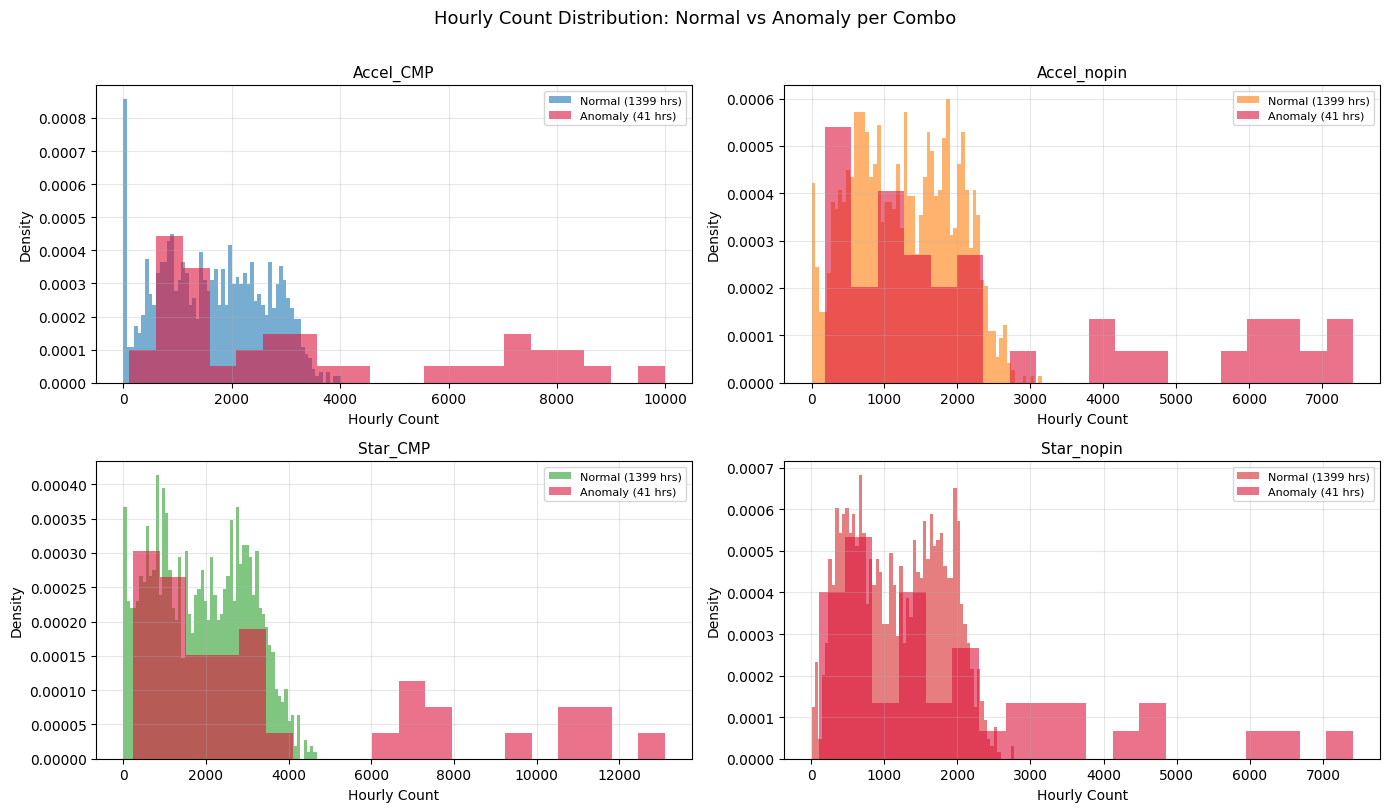

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, combo in enumerate(COMBO_KEYS):
    ax = axes[i // 2][i % 2]
    h = combo_data[combo]
    label = combo_labels[combo]
    
    normal_mask = h["is_anomaly"] == 0
    anomaly_mask = h["is_anomaly"] == 1
    
    ax.hist(h.loc[normal_mask, "count"], bins=60, alpha=0.6, color=colors[label],
            label=f"Normal ({normal_mask.sum()} hrs)", density=True)
    if anomaly_mask.sum() > 0:
        ax.hist(h.loc[anomaly_mask, "count"], bins=20, alpha=0.6, color="crimson",
                label=f"Anomaly ({anomaly_mask.sum()} hrs)", density=True)
    
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Hourly Count")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Hourly Count Distribution: Normal vs Anomaly per Combo", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 7. Anomaly Hours: Spike vs Dip Breakdown

Categorize anomaly hours by direction: does the anomalous count fall above or below the normal baseline?

In [9]:
print(f"{'Combo':<15} {'Total Anom':>10} {'Spikes':>8} {'Dips':>8} {'Ambiguous':>10}")
print("-" * 55)

for combo in COMBO_KEYS:
    h = combo_data[combo]
    label = combo_labels[combo]
    counts = h["count"].values
    anomalies = h["is_anomaly"].values
    
    # Train mean per hour-of-day
    train_days = 42
    daily_matrix = counts[:train_days * 24].reshape(-1, 24)
    mean_by_hour = daily_matrix.mean(axis=0)
    std_by_hour = daily_matrix.std(axis=0)
    
    spikes = 0
    dips = 0
    ambiguous = 0
    
    for hour_idx in range(len(counts)):
        if anomalies[hour_idx] == 1:
            hod = hour_idx % 24
            deviation = counts[hour_idx] - mean_by_hour[hod]
            if deviation > std_by_hour[hod]:
                spikes += 1
            elif deviation < -std_by_hour[hod]:
                dips += 1
            else:
                ambiguous += 1
    
    total = int(anomalies.sum())
    print(f"{label:<15} {total:>10} {spikes:>8} {dips:>8} {ambiguous:>10}")

Combo           Total Anom   Spikes     Dips  Ambiguous
-------------------------------------------------------
Accel_CMP               41       19        9         13
Accel_nopin             41       19       12         10
Star_CMP                41       23       10          8
Star_nopin              41       23       10          8


## Summary

The 4 combo time series show:

- **Diverse periodicities** — 24h (Accel_CMP, Star_CMP), 12h (Accel_nopin), and 8h (Star_nopin) cycles, confirmed by FFT
- **High base rates** — 1200-2000 txns/hour, with natural day-to-day variability and hourly noise
- **Bidirectional anomalies** — both spikes (3x surges) and dips (90% drops) are injected, unlike the penny use case which only has spikes
- **Combo-specific dip targeting** — dips hit each combo's peak hour for maximum visibility

The FCVAE is well-suited because its **GFM (Global Frequency Module)** automatically adapts to each combo's dominant periodicity via FFT, while the **LFM (Local Frequency Module)** captures shorter-range trends. A single architecture handles all 4 patterns without combo-specific tuning.

**Next:** See `2_combo_anomaly_detection.ipynb` for spike/dip/ramp detection with pre-trained models, score distributions, and F1 metrics.